In [1]:
import numpy as np
import pickle


In [2]:
def get_functions(data, tokens, token_ids):
    sep_idx = token_ids["<SEP>"]
    functions = []
    for doc in data:
        first_sep_pos = np.where(doc == sep_idx)[0][0]
        function_list = [tokens[token_id] for token_id in doc[1:first_sep_pos]]
        functions.append(function_list)
    return functions

In [3]:
from typing import List
def calculate_position_distribution(functions: List, token_idx_map: dict, K: int) -> np.ndarray:
        """
        Calculate P(token at position) for all tokens and positions.
        Returns: K x K matrix where entry [i,j] = P(token i+1 at position j)
        """
        dist = np.zeros((K, K))
        
        for function in functions:
            for pos, token in enumerate(function):
                dist[pos, token_idx_map[token]] += 1
        
        # Normalize by number of permutations
        dist = dist / len(functions)
        return dist
    
def calculate_pairwise_distribution(functions: List, token_idx_map: dict, K: int) -> np.ndarray:
    """
    Calculate P(token j follows token i) for all ordered pairs.
    Returns: K x K matrix where entry [i,j] = P(token j+1 follows token i+1)
    """
    dist = np.zeros((K, K))
    
    for function in functions:
        for i in range(len(function) - 1):
            token_i = token_idx_map[function[i]]
            token_j = token_idx_map[function[i+1]]
            dist[token_i, token_j] += 1
    
    # Normalize by total number of adjacencies
    total_adjacencies = len(functions) * (K - 1)
    dist = dist / total_adjacencies
    return dist

def kl_divergence(p: np.ndarray, q: np.ndarray, epsilon: float) -> float:
        """
        Calculate KL divergence D_KL(P || Q).
        Add small epsilon to avoid log(0).
        """
        # with a tolerance of 1e-6
        
        assert np.abs(np.sum(p) - 1) < 1e-6, "p must sum to 1"
        assert np.abs(np.sum(q) - 1) < 1e-6, "q must sum to 1"
        p = p + epsilon
        q = q + epsilon
        # Renormalize
        p = p / np.sum(p)
        q = q / np.sum(q)
        
        return np.sum(p * np.log(p / q))

def position_coverage_divergence_kl(train_dist: np.ndarray, 
                                       test_dist: np.ndarray, epsilon: float) -> float:
        """
        Calculate Position Coverage Divergence using KL divergence.
        Average KL divergence across all tokens.
        """
        kl_sum = 0
        for i in range(K):
            kl_sum += kl_divergence(test_dist[i, :], train_dist[i, :], epsilon)
        
        return kl_sum / K

def pairwise_adjacency_divergence_kl(train_dist: np.ndarray, 
                                    test_dist: np.ndarray, epsilon: float) -> float:
    """
    Calculate Pairwise Adjacency Divergence using KL divergence.
    Average KL divergence across all tokens.
    """
    return kl_divergence(test_dist.flatten(), train_dist.flatten(), epsilon)
   
        

In [20]:
train_splits = ["combination_2", "combination_3", "combination_4", "combination_5", "combination_6"]
from matplotlib import pyplot as plt
pcd_values = {}
pad_values = {}
for train_split in train_splits:
    pcd_values[train_split] = []
    pad_values[train_split] = []
    for test_split in ["combination_1", "combination_2", "combination_3", "combination_4", "combination_5", "combination_6"]:
        train_data_path = f"/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/data/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_7/step_by_step/{train_split}/train_step_by_step_corpus.npy"
        train_token_path = f"/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/data/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_7/step_by_step/{train_split}/token.pkl"
        train_token_id_path = f"/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/data/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_7/step_by_step/{train_split}/token_idx.pkl"
        test_data_path = f"/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/data/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_7/step_by_step/{test_split}/train_step_by_step_corpus.npy"
        test_token_path = f"/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/data/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_7/step_by_step/{test_split}/token.pkl"
        test_token_id_path = f"/project/pi_jensen_umass_edu/ppruthi_umass_edu/module_identification/data/uniform/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_7/step_by_step/{test_split}/token_idx.pkl"

        train_data = np.load(train_data_path)
        train_tokens = pickle.load(open(train_token_path, "rb"))
        train_token_ids = pickle.load(open(train_token_id_path, "rb"))

        test_data = np.load(test_data_path)
        test_tokens = pickle.load(open(test_token_path, "rb"))
        test_token_ids = pickle.load(open(test_token_id_path, "rb"))
        train_functions = get_functions(train_data, train_tokens, train_token_ids)
        test_functions = get_functions(test_data, test_tokens, test_token_ids)
        
        # convert list to tuple to include in set
        train_functions = [tuple(function) for function in train_functions]
        test_functions = [tuple(function) for function in test_functions]

        # get unique functions
        unique_train_functions = list(set(train_functions))
        unique_test_functions = list(set(test_functions))

        unique_tokens = []
        for function in train_functions:
            for token in function:
                unique_tokens.append(token)
        unique_tokens = list(set(unique_tokens))
        
        token_idx_map = {}
        for i, token in enumerate(unique_tokens):
            token_idx_map[token] = i
        K = 7
        train_pos_dist = calculate_position_distribution(train_functions, token_idx_map, K)
        test_pos_dist = calculate_position_distribution(test_functions, token_idx_map, K)
        train_pair_dist = calculate_pairwise_distribution(train_functions, token_idx_map, K)
        test_pair_dist = calculate_pairwise_distribution(test_functions, token_idx_map, K)
        # print(train_pos_dist)
        # print(test_pos_dist)
        # print(train_pair_dist)
        # print(test_pair_dist)
        epsilon = 1e-10
        print("Train Split: ", train_split)
        print("Test Split: ", test_split)
        pcd = position_coverage_divergence_kl(train_pos_dist, test_pos_dist, epsilon)
        print(" Position Coverage Divergence: ", pcd)
        pad = pairwise_adjacency_divergence_kl(train_pair_dist, test_pair_dist, epsilon)
        print(" Pairwise Adjacency Divergence: ", pad)
        pcd_values[train_split].append(pcd)
        pad_values[train_split].append(pad)


Train Split:  combination_2
Test Split:  combination_1
 Position Coverage Divergence:  0.09315002310678781
 Pairwise Adjacency Divergence:  0.1427793880987982
Train Split:  combination_2
Test Split:  combination_2
 Position Coverage Divergence:  0.0
 Pairwise Adjacency Divergence:  0.0
Train Split:  combination_2
Test Split:  combination_3
 Position Coverage Divergence:  0.047482601092636675
 Pairwise Adjacency Divergence:  0.122459240568968
Train Split:  combination_2
Test Split:  combination_4
 Position Coverage Divergence:  0.17879258241632107
 Pairwise Adjacency Divergence:  0.4583329902156468
Train Split:  combination_2
Test Split:  combination_5
 Position Coverage Divergence:  0.3945980837702841
 Pairwise Adjacency Divergence:  1.0127601918830682
Train Split:  combination_2
Test Split:  combination_6
 Position Coverage Divergence:  0.7142721127621211
 Pairwise Adjacency Divergence:  1.826990474323888
Train Split:  combination_3
Test Split:  combination_1
 Position Coverage Diverg

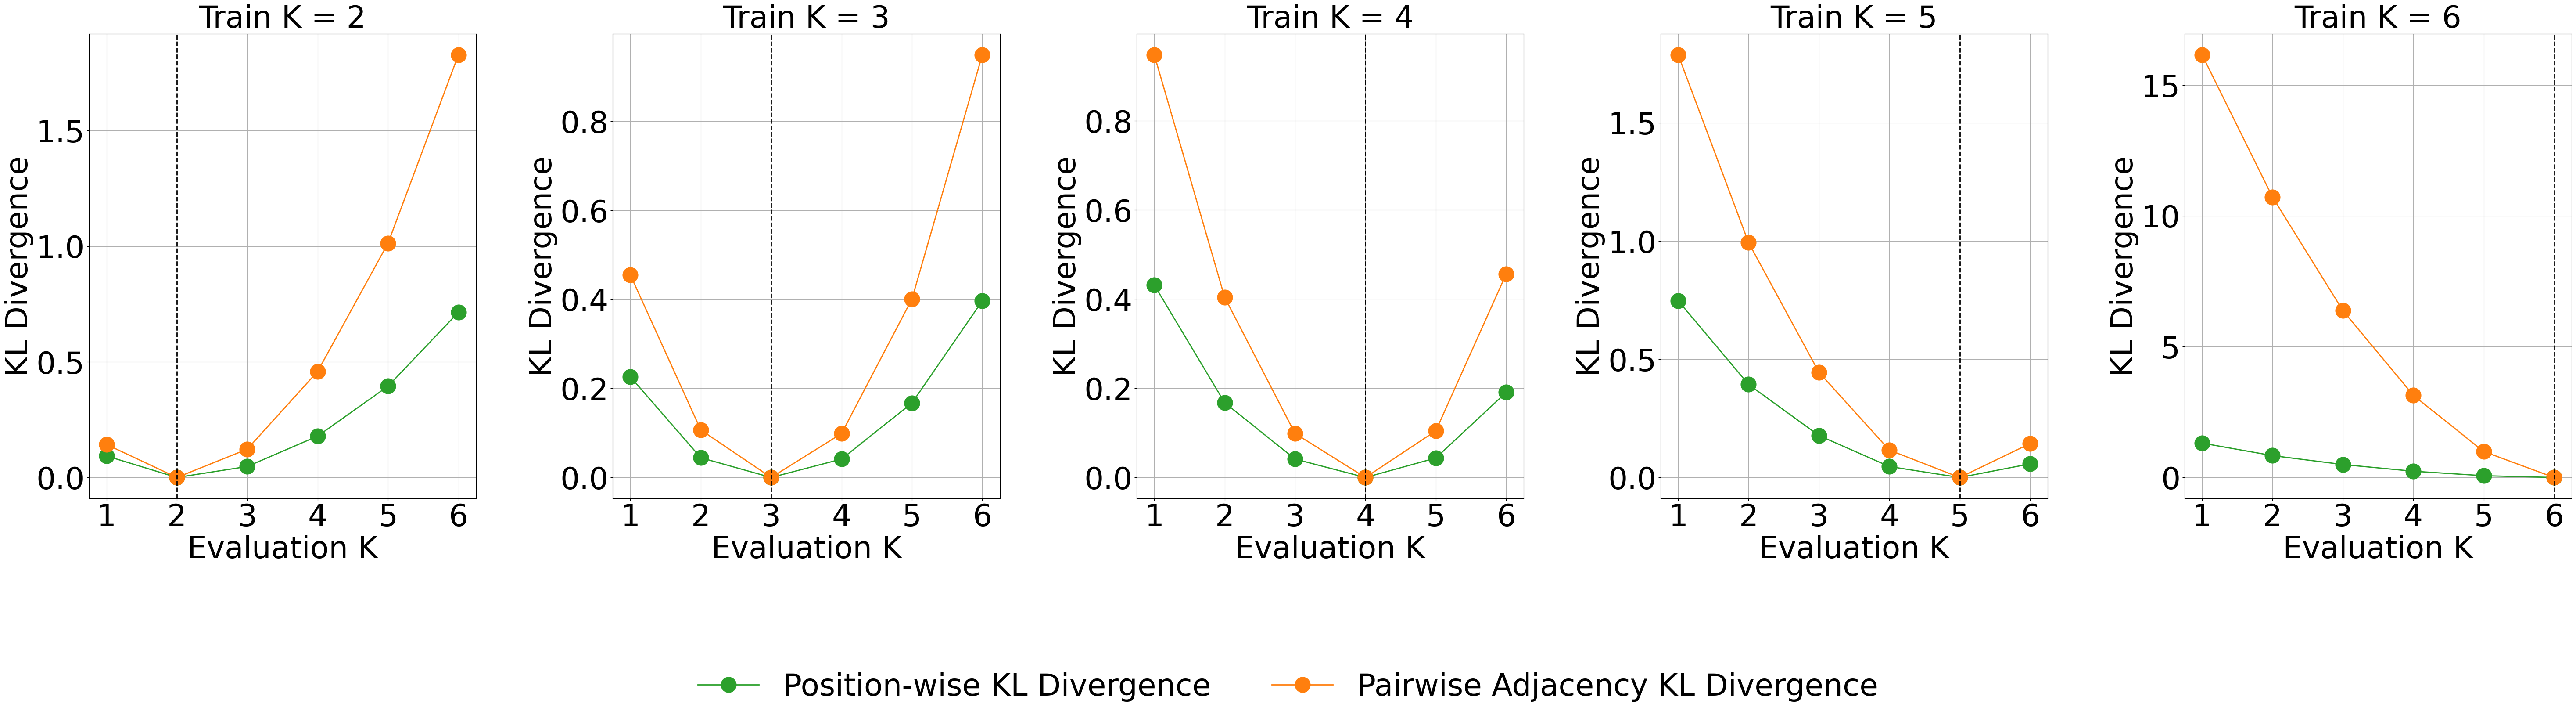

In [38]:
# plot the divergence
# plot line plot for with and without identity results side by side four plots with legend below 
from matplotlib import pyplot as plt
import numpy as np

font_size = 50
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
pos_kl_values = [0.034, 0.515, 1.009, 1.625, 2.164, 2.575, 3.061, 4.299, 4.671]
function_types = ["uniform"]

pos_types = ["abs", "rel_global"]
length = "fixed"

fig, axs = plt.subplots(1, 5, figsize=(60, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["step_by_step", "direct"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for i, train_split in enumerate(train_splits):

    x_axis = [1, 2, 3, 4, 5, 6]
    axs[i].plot(x_axis, pcd_values[train_split], label="Position-wise KL Divergence", color="tab:green", marker="o", linestyle="-",markersize=font_size/2, linewidth=2)
    axs[i].plot(x_axis, pad_values[train_split], label="Pairwise Adjacency KL Divergence", color="tab:orange", marker="o", linestyle="-",markersize=font_size/2, linewidth=2)
    # have black vertical dotted line at x=3
    axs[i].axvline(x=i+2, color="black", linestyle="--", markersize=font_size/2, linewidth=2)
    # x-axis is the test split
    axs[i].set_xlabel("Evaluation K")
    axs[i].set_ylabel("KL Divergence")
    axs[i].set_xticks([1, 2, 3, 4, 5, 6])
    axs[i].set_title(f"Train K = {train_split.split('_')[-1]}", fontsize=font_size)
    
    axs[i].grid(True)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=font_size, bbox_to_anchor=(0.5, -0.15), frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("cross_k_divergence_values.pdf", dpi=300, bbox_inches='tight')

